# **Deep Learning**
* 머신러닝의 특정한 한 분야로 연속된(Deep) 층(Layer)을 통해 학습
* 인공신경망 기반 모델로 <b> <font color=blue> 비정형 데이터로부터 특징 추출 및 판단까지 기계가 한번에 수행
* <b> Input, Transfer Function, Activation Function, Output

uSLP / MLP(히든레이어) / DNN

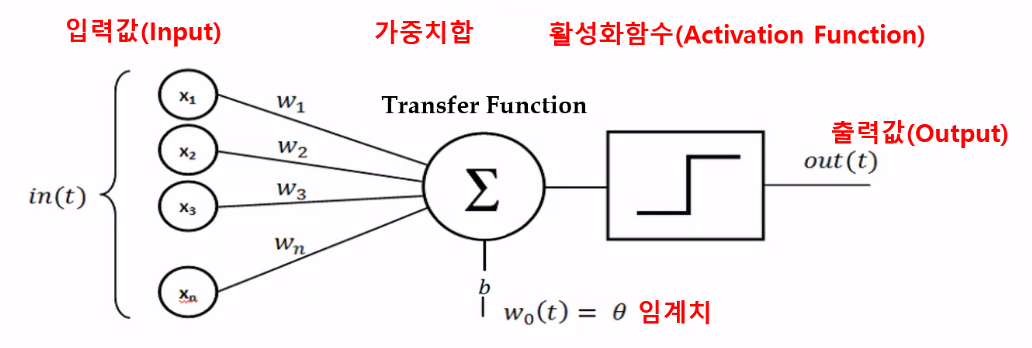

* Step1 : 임의의 w, b값 설정
* Step2 : 훈련 데이터셋 사용 y값 예측 (wx+b)
* Step3 : 예측값과 실제값 사이 오차(=loss, 손실값) 계산 (손실함수 : mse)
* Step4 : 순방향학습(포워드)_오차를 줄이는 방향으로 w, b 수정 / 역전파(백워드/백프로파게이션)_오차를 줄이는 방향으로 앞 layer의 w, b 수정 <<<-------- 이걸 판단하는 것 : 옵티마이저<br>
* Step5 : 오차값 최소가 될 때까지 Step2-4 반복 <br>
<b>※에폭(Epoch) : 전체 훈련 데이터셋을 모델이 정확히 한 번씩 전부 통과하며 학습(순전파+역전파)한 주기

## **인공신경망 종류**

* 심층신경망(Depp Neural Network, DNN)
* 합성곱신경망(Convolution Neural Network, CNN) : 이미지 분석
* 순환신경망(Recurrent Neural Network, RNN) : 언어모델/시계열 분석
* 완전연결신경망(Fully Connected Neural Network, FCNN) : 회귀 or 분류 판단

## **Activation Function(활성화함수)**

* Transfer Function으로부터 전달받은 값을 출력 시 일정 기준에 따라 출력값을 변화시키는 비선형 함수
* 히든레이어에서 : 아무거나(ReLu)
* 아웃풋레이어에서 : 이중/다중분류에 따라 
<img width=700 src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSq-jNmcsCv8Jd6qt_SzktDKYn_aFKYFXIiMxUumNbKcx0VyZrrfxXqp8We&s=10">

## **XOR(배타적 논리합)**
두 개의 입력이 서로 다를 때만 1(참)을 출력하고, 서로 같으면 0(거짓)을 출력하는 논리 연산

**→ 진리표(Truth Table)**
* 0 XOR 0 = 0 (같으므로 0)
* 0 XOR 1 = 1 (다르므로 1)
* 1 XOR 0 = 1 (다르므로 1)
* 1 XOR 1 = 0 (같으므로 0)

## **Optimization(가중치 최적화) 기법**

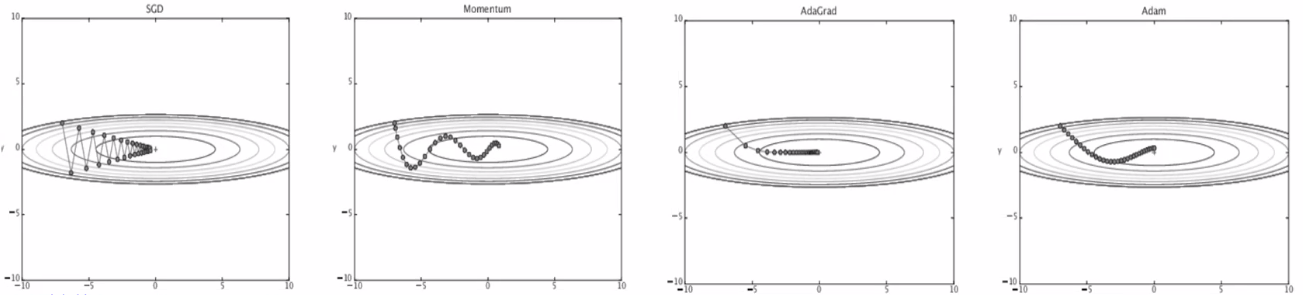

### **경사하강법(Gradient Descent, GD)**
* 현재 지점의 기울기(편미분)에서 learning rage를 곱한 값을 뺀 값이 최적화가 되도록 하강
* 주어진 데이터셋 전체에 대해 한번에 기울기를 계산해 가중치를 갱신 : 메모리 낭비, 느리다, 오버피팅

### **모멘텀(Momentum)**
* 기울기 방향으로 힘을 받아 가속(velocity)하며 하강
* 공이 그릇 바닥을 구르는 듯한 움직임
* 이동했던 방향에 관성이 있어 local-minimum에 빠지는 것을 방지

### **확률적경사하강법(Stochastic Gradient Descent, SGD)**
* mini batch로 빠르게 최적값을 찾아가며 하강
* 방향에 따라 기울기가 달라지는 비등방성(anisotropy) 함수에서는 탐색 경로 비효율적

### <font color=blue>**AdaGrade**
* 매개변수의 원소마다 적응적으로 학습률 조정
* 매개변수의 원소 중 크게 갱신된 원소는 학습률을 낮춤(매개변수마다 가중치 다르게 적용)
* 과거 기울기 제곱하며 학습률을 줄여나감

### <font color=blue>**Adam**
* 모멘텀(방향성) + AdaGrade(차등성 가중치)

## **가중치 초기값 설정**

### **Sigmoid : Xavier**
* Xavier 초기값 = Sigmoid에 특화됨
* 앞·뒤 계층 노드 수를 고려해 가중치를 초기화하여 학습을 안정적으로 함

### **ReLu : He**
* He 초기값 = ReLu에 특화됨
* 앞계층의 노드가 n일 때 가중치 분산을 \(2/n\)로 설정해 학습이 안정적으로 되게 함

## **가중치 감소(Weight Decay)**
* 학습 중 가중치가 큰 것에 패널티를 부과해 과적합(오버피팅)의 위험을 줄임
* 큰 가중치에 벌점 → 가중치 작아짐 → 과적합 감소
* 대표적으로 L1 규제(Lasso)와 L2 규제(Ridge)

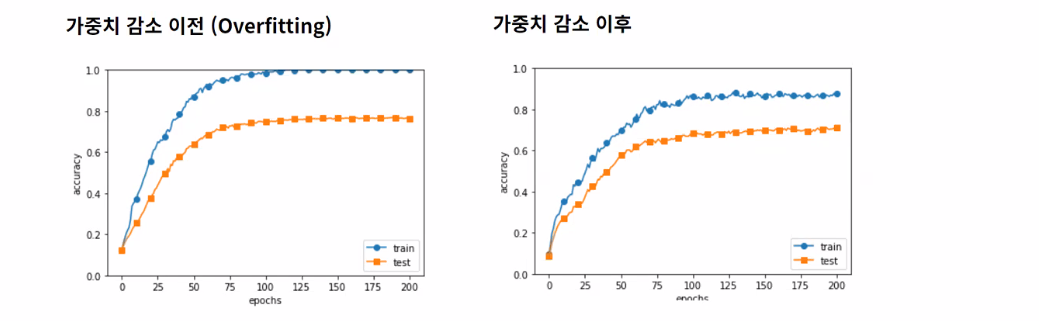

## **Dropout**
* 데이터 훈련 시 오버피팅 방지를 위해 뉴런의 연결을 임의로 삭제
* 테스트 시 모든 뉴런을 사용

<img width=600 src="https://kh-kim.github.io/nlp_with_deep_learning_blog/assets/images/1-14/04-dropout_overview.png">

인풋개수 : 첫번째레이어만 해당
각 레이어마다 아웃풋은 맘대로 조정
값 하나 : 회귀 : AF 없음
두개 : 이진분류
세개 이상 : 다중분류


--------------------------------------------

# **[1] 딥러닝 기초 : 회귀**

In [1]:
from sklearn import set_config
set_config(display="text")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split                   #문제/답 분리

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)

from keras.models import Sequential
from keras.layers import Dense, Flatten

In [2]:
df = pd.read_csv("../../Datas/#BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
y = y = df['medv']
X = df.drop(columns=["medv"])
X_train7, X_test3, y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234)

* LinearRegression() mse 1차 점수 : 4.9105
* LinearRegression() mse outlier : 4.4170
* Ridge L2 규제 적용 mse : 4.2175

In [4]:
#Dense?

In [5]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [6]:
model = Sequential([
        Dense(units=16, activation='relu', input_dim=13),
        Dense(units=18, activation='relu'),
        Dense(units=20, activation='relu'),
        Dense(units=8, activation='relu'),
        Dense(units=1)
     ])
model.compile(loss="mse", optimizer="adam", metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
# compile = 메모리에 올린다 / "lom" 중요!

C:\IT\python_workspace\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 18)                  │             306 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,087 (4.25 KB)

 Trainable params: 1,087 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
fit_res = model.fit( X_train7, y_train7, batch_size=4, epochs=20, validation_data=(X_test3, y_test3) )
# ------------------------------------ 4개씩 학습, 백워드 20번 보정, 자체검증 위한 test 데이터 입력

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 115.2004 - rmse: 10.7331 - val_loss: 84.8181 - val_rmse: 9.2097
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 76.4725 - rmse: 8.7449 - val_loss: 77.6622 - val_rmse: 8.8126
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71.8173 - rmse: 8.4745 - val_loss: 72.1256 - val_rmse: 8.4927
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68.4802 - rmse: 8.2753 - val_loss: 70.0007 - val_rmse: 8.3666
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 66.4173 - rmse: 8.1497 - val_loss: 65.7440 - val_rmse: 8.1083
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.1119 - rmse: 7.9443 - val_loss: 67.6981 - val_rmse: 8.2279
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62.7246 - rmse: 7.9199 - val_loss: 65.5110 - val_rmse: 8.0939
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60.5889 - rmse: 7.7839 - val_loss: 63.4194 - val_rmse: 7.9636
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
# loss: 43.6106 - rmse: 6.6038 - val_loss: 54.0372 - val_rmse: 7.3510
fit_res.history['loss'][:5], fit_res.history['val_rmse'][:5]

([115.20044708251953,
  76.47252655029297,
  71.81725311279297,
  68.4802474975586,
  66.41726684570312],
 [9.209673881530762,
  8.812613487243652,
  8.49267864227295,
  8.366640090942383,
  8.108269691467285])

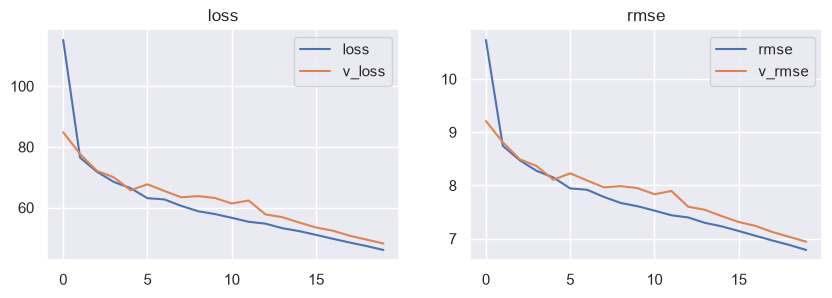

In [10]:
plt.figure(figsize=(10,3))
ax1 = plt.subplot(1,2,1)
ax1.plot(fit_res.history['loss'], label="loss")
ax1.plot(fit_res.history['val_loss'], label="v_loss")
ax1.legend()
ax1.set_title("loss")

ax2 = plt.subplot(1,2,2)
ax2.plot(fit_res.history['rmse'], label="rmse")
ax2.plot(fit_res.history['val_rmse'], label="v_rmse")
ax2.legend()
ax2.set_title("rmse")

plt.show()

In [11]:
res = model.evaluate(X_test3, y_test3)
print( f"rmse : {res[1]:.4f}" )
# loss: 54.0372 - rmse: 7.3510 <<< 이거(1번째) 필요

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.2059 - rmse: 6.9430 
rmse : 6.9430


# **[2] 딥러닝 기초 : 분류**

* 이진분류 : 마지막 레이어 activation=sigmoid, 손실함수 binary_crossentropy
* 다중분류 : 마지막 레이어 activation=softmax  OR  손실함수 sparse_categorical_crossentropy

In [12]:
df = pd.read_csv("../../Datas/#pima/train.csv") 
df.columns = df.columns.str.lower()
df = df.rename(columns={'bloodpressure':'blood',
                              'skinthickness' : 'skin',
                              'diabetespedigreefunction': 'diabet'})

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  616 non-null    int64  
 1   glucose      616 non-null    int64  
 2   blood        616 non-null    int64  
 3   skin         616 non-null    int64  
 4   insulin      616 non-null    int64  
 5   bmi          616 non-null    float64
 6   diabet       616 non-null    float64
 7   age          616 non-null    int64  
 8   outcome      616 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 43.4 KB


* 3차점수 - f1 : 0.7385
* 4차점수 - f1 : 0.7200

In [14]:
y = y = df['outcome']
X = df.drop(columns=["outcome"])
X_train7, X_test3, y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234)

In [15]:
model = Sequential([
        Dense(units=16, activation='relu', input_dim=8),
        Dense(units=18, activation='relu'),
        Dense(units=20, activation='relu'),
        Dense(units=8, activation='relu'),
        Dense(units=1, activation='sigmoid')
     ])
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=[tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_score')])
#------------분류는 loss=binary_crossentropy

C:\IT\python_workspace\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 18)                  │             306 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 20)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,007 (3.93 KB)

 Trainable params: 1,007 (3.93 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
fit_res = model.fit( X_train7, y_train7, batch_size=4, epochs=30, validation_data=(X_test3, y_test3) )
# 

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 0.2796 - loss: 0.8912 - val_f1_score: 0.0822 - val_loss: 0.6849
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.2660 - loss: 0.6352 - val_f1_score: 0.2558 - val_loss: 0.6681
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.2682 - loss: 0.6112 - val_f1_score: 0.2727 - val_loss: 0.6535
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.3011 - loss: 0.5996 - val_f1_score: 0.2697 - val_loss: 0.6601
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.3094 - loss: 0.5896 - val_f1_score: 0.2697 - val_loss: 0.6519
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.3297 - loss: 0.5856 - val_f1_score: 0.2118 - val_loss: 0.6521
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.3051 - loss: 0.5835 - val_f1_score: 0.2469 - val_loss: 0.6438
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.2941 - loss: 0.5765 - val_f1_score: 0.

In [18]:
res = model.evaluate(X_test3, y_test3)
print( f"f1_score : {res[1]:.4f}" )     # --------------- 완전 오버피팅! (레이어 쌓기, 드롭아웃 하기 등 하면서 조정)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - f1_score: 0.3617 - loss: 0.7008 
f1_score : 0.3617


# **[3] 딥러닝 기초 : 이미지 분석**
* https://keras.io/api/datasets/fashion_mnist/

<pre>
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot

In [19]:
from keras.datasets.fashion_mnist import load_data

In [20]:
(X_train, y_train), (X_test, y_test) = load_data()
print( X_train.shape, X_test.shape, y_train.shape, y_test.shape )

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [21]:
X_train[0]
# 28*28, 숫자=이미지RGB

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

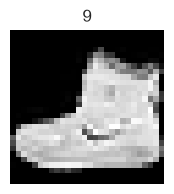

In [22]:
# --------- 이미지 픽셀 시각화

plt.figure(figsize=(2, 2)) 
plt.imshow(X_train[0], cmap='gray', vmin=0, vmax=255) 
plt.title("Grayscale Pixel Visualization") 
plt.axis('off') # 픽셀 좌표 축 표시 ('off'로 하면 숨겨집니다) plt.show()
plt.title(f"{y_train[0]}")
plt.show()

In [23]:
LABEL_NAME__ = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

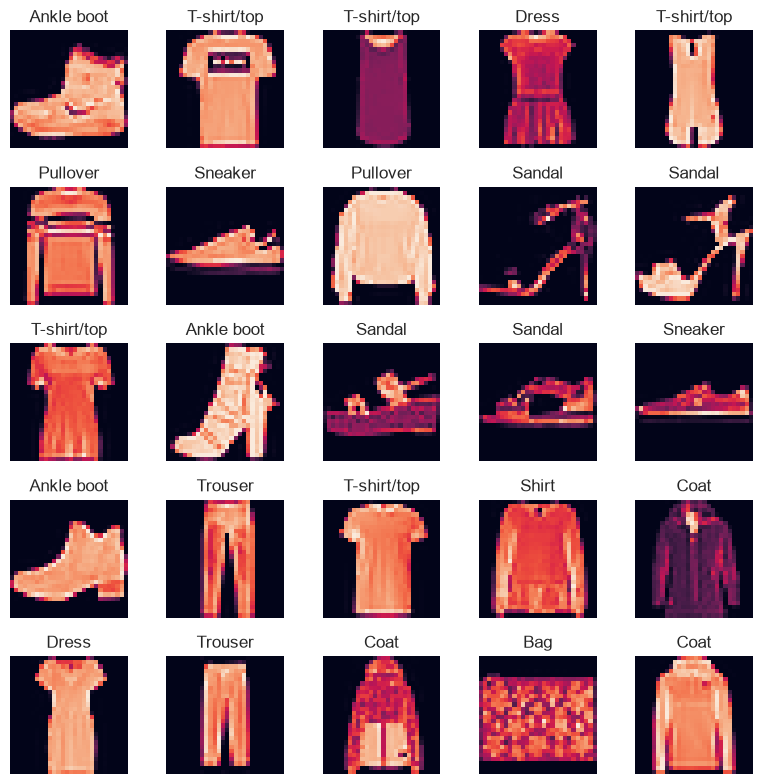

In [24]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.grid(False)
    plt.axis('off')
    plt.imshow(X_train[i])
    plt.title(LABEL_NAME__[y_train[i]])
plt.tight_layout()
plt.show()

## **MinMaxScaler**
* min = 0, max = 255
* 차이가 크니 0, 1로 전처리
* transform or 나누기 255

In [25]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
model = Sequential([
        Flatten(input_shape=(28, 28)),    # ---------------- Flatten = 28*28을 한줄로 펴지게 함  /  dimension(몇차) = 28*28 = 784
        Dense(units=280, activation='relu'), 
        Dense(units=160, activation='relu'),
        Dense(units=80, activation='relu'),
        Dense(units=120, activation='relu'),
        Dense(units=80, activation='relu'),
        Dense(units=60, activation='relu'),
        Dense(units=20, activation='relu'),
        Dense(units=10, activation='softmax')  # -------- 다중분류는 softmax]
            ])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])
# ----------- 다중분류 손실함수 sparse

C:\IT\python_workspace\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 280)                 │         219,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 160)                 │          44,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 80)                  │          12,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 120)                 │           9,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 80)                  │           9,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 60)                  │           4,860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 20)                  │           1,220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 303,330 (1.16 MB)

 Trainable params: 303,330 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
fit_res = model.fit( X_train, y_train, batch_size=256, epochs=20, validation_data=(X_test, y_test) )

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7613 - loss: 0.6859 - val_accuracy: 0.8296 - val_loss: 0.4753
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8536 - loss: 0.4052 - val_accuracy: 0.8559 - val_loss: 0.3962
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8693 - loss: 0.3546 - val_accuracy: 0.8670 - val_loss: 0.3688
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8798 - loss: 0.3254 - val_accuracy: 0.8667 - val_loss: 0.3643
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8855 - loss: 0.3070 - val_accuracy: 0.8725 - val_loss: 0.3537
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8928 - loss: 0.2885 - val_accuracy: 0.8784 - val_loss: 0.3434
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8979 - loss: 0.2733 - val_accuracy: 0.8754 - val_loss: 0.3559
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.2614 - val_accuracy: 0.

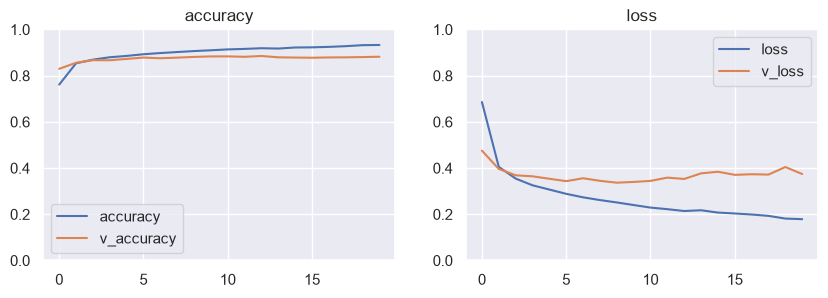

In [31]:
plt.figure(figsize=(10,3))
ax1 = plt.subplot(1,2,1)
ax1.plot(fit_res.history['accuracy'], label="accuracy")
ax1.plot(fit_res.history['val_accuracy'], label="v_accuracy")
ax1.legend()
ax1.set_ylim(0, 1)
ax1.set_title("accuracy")

ax2 = plt.subplot(1,2,2)
ax2.plot(fit_res.history['loss'], label="loss")
ax2.plot(fit_res.history['val_loss'], label="v_loss")
ax2.legend()
ax2.set_ylim(0, 1)
ax2.set_title("loss")

plt.show()

In [30]:
res = model.evaluate(X_test, y_test)
print( f"accuracy : {res[1]:.4f}" )

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8819 - loss: 0.3743  
accuracy : 0.8819
